In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

In [4]:
f(5)

60

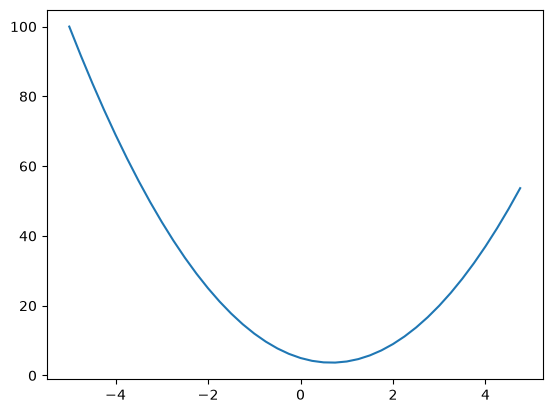

In [5]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [55]:
#Aumentar un 0.01
x = 0
print(f(x))
print(f(x+1))
print("Diferencia:", f(x+1) - f(x))

#Primera conclusion
print("Los valores que aumentes en cierto punto, pueden generar un aumento grande o pequeño, pero tambien una decrecimiento")

5
4
Diferencia: -1
Los valores que aumentes en cierto punto, pueden generar un aumento grande o pequeño, pero tambien una decrecimiento


In [85]:
#Concepto de Derivada
#En palabras faciles, la derivada trata de medir la tasa de cambio de una funcion en un punto.
def local():
    x = 5
    h = 0.001
    print(f(x))
    print(f(x+h))
    print("Derivada:", (f(x+h) - f(x))/h)
    print("La diferencia DEBERIA SER EL PASO x LA GRADIENTE:", h*((f(x+h) - f(x))/h))
    print("Diferencia real:", f(x+h) - f(x))

In [86]:
local()

60
60.026003
Derivada: 26.003000000002885
La diferencia DEBERIA SER EL PASO x LA GRADIENTE: 0.026003000000002885
Diferencia real: 0.026003000000002885


In [87]:
def f(x):
    return 3*x**2 - 4*x + 5

In [2]:
h = 0.001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a+=h
d2 = a*b + c

In [8]:
## Obtener el slope basado en restas diferenciales o la llamada Cociente de newton
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)
#derivada real
#dd/da = d(a*b) + d(c) = b + 0 = b
print('slope real basada en derivadas:', b)
print('diferencia real basada en derivada:', h * ((d2-d1)/h))
print('diferencia real basado en resta:', d2-d1)

d1 4.0
d2 3.997
slope -3.0000000000001137
slope real basada en derivadas: -3.0
diferencia real basada en derivada: -0.0030000000000001137
diferencia real basado en resta: -0.0030000000000001137


In [5]:
## Codigo de Backpropagation

from cProfile import label
from typing import Optional

 
class Value:
    def __init__(self, data, _children=(), _op = '',label=''):
        self.data = data
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
        self.grad = 0.0
    
    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(data = self.data + other.data, _children = (self, other), _op = "+")

        def _backward():
            self.grad += 1 * out.grad ##Apuntamos a estos nodos basado en el resultado, si hacemos back,  el resultado ya tiene un .grad, por lo que con eso multiplicamos como haciendo derivadas y asiganamos grads
            other.grad += 1* out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        out = Value(data = self.data * other.data, _children = (self, other), _op = "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x)+1)
        out = Value(data = t, _children=(self,), _op= "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        
        out = Value(0 if self.data <0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out


    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        
        build_topo(self)
        self.grad = 1
        for node in reversed(topo):
            node._backward()



In [6]:
##Graficador
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [8]:
#Backprop manual con valores simples

h = 0.001

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a*b; e.label = 'e'
f = Value(-2.0, label= 'f')
L = e+f; L.label='L'
L1 = L.data ##aca estamos sobrescribiendo L1 con la data directa sin el value


#Backprop manual con valores simples
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
f = Value(-2.0, label= 'f')
L = e+f; L.label='L'
L2 = L.data ##aca estamos sobrescribiendo L2 con la data directa sin el value

print('Slope/Derivada:', ((L2-L1)/h))
print('Valor adicional: ', h)
print('Diferencia predecida:', h * ((L2-L1)/h))
print('Diferencia Real:', L2-L1)


Slope/Derivada: 0.0
Valor adicional:  0.001
Diferencia predecida: 0.0
Diferencia Real: 0.0


In [21]:
L.grad = 1


#Obtener la grad de L respecto a e
# L = e + f
# dL/de = de/de + df/de
# dL/de = 1 + 0
# dL/de = 1
# Sabiendo en una suma, dL/de y dL/df = 1

e.grad = 1
f.grad = 1

## Queremos obtener las grad de L respecto a A y B
# e = a * b
# de/da = b
# de/db = a
#por la chain rule
# dL/da = de/da * dL/de
# dL/da = b * 1 #1 es la grad de e si recuerda
# dL/db = a * 1

a.grad = b.data
b.grad = a.data

#esta es la forma matematica, arriba se comprueba sumando el h a la variable


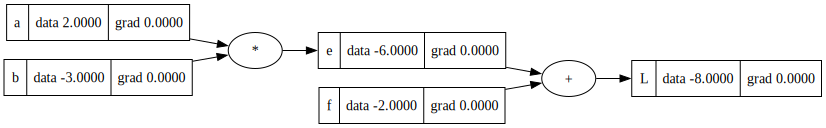

In [9]:
draw_dot(L)

In [10]:
## Ahora con Tanh
#Esta es una activation function para lograr hacer que las salidas pueden tener varias cosas
xs = np.arange(-5, 5, 0.25)
ys = np.tanh(xs)

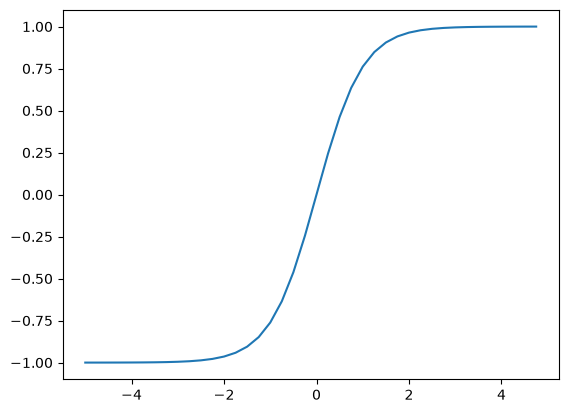

In [11]:
plt.plot(xs,ys)

In [14]:
h = 0.001

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label='o'
o1 = o.data

## segunda parte para VERIFICAR que estamos finos en gradientes
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label='o'
o2 = o.data 

print('Slope/Derivada:', ((o2-o1)/h))
print('Valor adicional: ', h)
print('Diferencia predecida:', h * ((o2-o1)/h))
print('Diferencia Real:', o2-o1)

Slope/Derivada: 0.0
Valor adicional:  0.001
Diferencia predecida: 0.0
Diferencia Real: 0.0


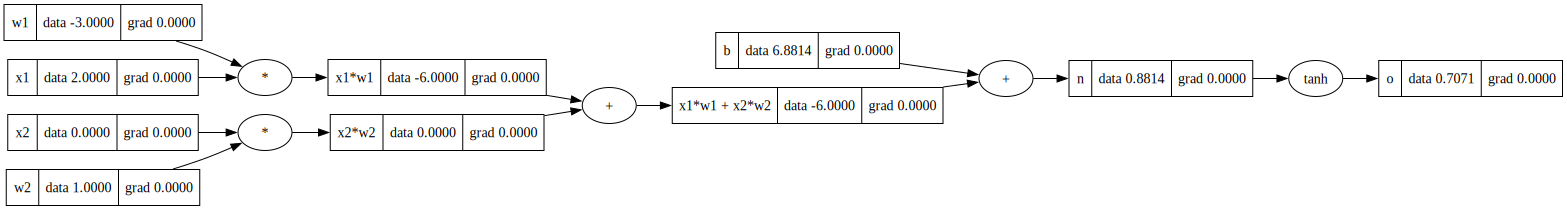

In [15]:
draw_dot(o)

In [122]:
## Desarrollo manual
o.grad = 1

#o = tanh(n)
# do/dn = 1-tanh(n)**2
# tanhn = 1-o**2 #Value(data=0.7071067811865476)
n.grad = 0.5000000000000001

#do/db = dn/db * do/dn
#do/db = dn/db * 0.5
#do/db = 1*0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5

# para x1w1 y x2w2
#derivada local
# x1w1x2w2 = x1w1 + x2w2
# dx1w1x2w2/dx1w1 = 1
# dx1w1x2w2/dx2w2 = 1
#saber do/dx1w1 = dx1w1x2w2/dx1w1 * do/x1w1x2w2
# saber do/dx1w1 = 1 * 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5


##Ahora mentalmente
x1.grad = -1.5
w1.grad = 1

x2.grad = 0.5
w2.grad = 0

In [126]:
## Con backwards
o.grad = 1
o._backward()
n._backward()
x1w1x2w2._backward()

In [129]:
## Topo Sort
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

[Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

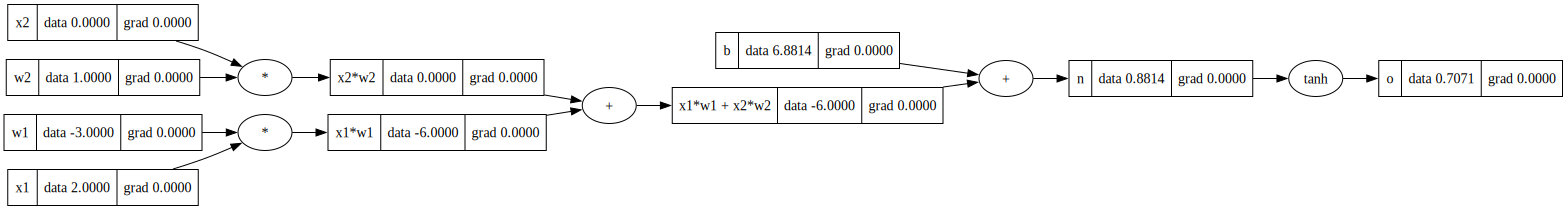

In [133]:
draw_dot(o)

In [16]:
o.backward()

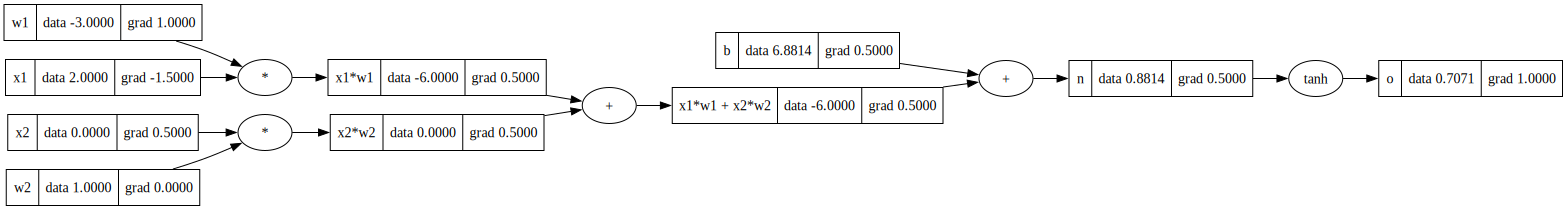

In [17]:
draw_dot(o)

## Neuron Layers

In [92]:

class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc
        self.label = label

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

In [93]:
from typing import Any


import random

class Neuron:

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act
    
    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}|Neuron({len(self.w)})"

class Layer:

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"
    

In [36]:
##Como sucede por una neurona de por si
xs = [2.0, 3.0, -4] ##La primera capa realmente, no es una capa neuronal por si misma, no tiene relu ni pesos ni nada
a = Neuron(3)
a(xs)

Value(data=0, grad=0)

In [37]:
xs = [2.0, 3.0, -4, 5]
a = Layer(4, 10)
print(len(a.parameters()))
for a in a.parameters(): ## 10 x 4, 4 viene de 3 pesos + 1 bias
    print(a)

50
Value(data=0.1221152064751978, grad=0)
Value(data=-0.32931920917665103, grad=0)
Value(data=0.6005037433093219, grad=0)
Value(data=-0.05011403728163066, grad=0)
Value(data=0, grad=0)
Value(data=0.7411253716916646, grad=0)
Value(data=0.9441776591947315, grad=0)
Value(data=-0.22648344053099878, grad=0)
Value(data=0.33422260173942253, grad=0)
Value(data=0, grad=0)
Value(data=-0.23729404096821427, grad=0)
Value(data=0.9331809792160812, grad=0)
Value(data=0.3724119709267346, grad=0)
Value(data=0.9965384306025833, grad=0)
Value(data=0, grad=0)
Value(data=0.520815425445732, grad=0)
Value(data=0.4281553779790872, grad=0)
Value(data=-0.6373052758380993, grad=0)
Value(data=0.4988207343468256, grad=0)
Value(data=0, grad=0)
Value(data=-0.4995275448232255, grad=0)
Value(data=0.4575951830366223, grad=0)
Value(data=0.34897589358130277, grad=0)
Value(data=-0.05341832974109506, grad=0)
Value(data=0, grad=0)
Value(data=-0.08885820729348826, grad=0)
Value(data=-0.6915978553049313, grad=0)
Value(data=0.

In [9]:
#Ejemplo para una casa
#Teniendo 2 variables de entrada: edad y tamaño de la casa

xs = [20, 1000]
first_layer = Layer(2, 4) ##2 por las variables y 4 neuronas que trabajaran para este caso
print("First Layer:")
out = first_layer(xs)

##Ahora, la siguiente capa usa las 4 salidas y genera 1 sola respuesta
second_layer = Layer(4,1)
print("Second Layer:")
out2 = second_layer(out)


First Layer:
[Value(data=877.1964601029116, grad=0), Value(data=0, grad=0), Value(data=727.154109074023, grad=0), Value(data=276.02491626457964, grad=0)]
Second Layer:
[Value(data=0, grad=0)]


In [10]:
##Si quremos saber la lista de parametros de la red neuronal de arriba es simple.
#Cuantos parametros tiene la primer capa?

#Como recibe 2 entradas, y 4 neuronas, tenemos 2 pesos + 1 bias por neurona
print("Prediccion parametros 1era capa: ", 4 * (2 + 1))

#Cuantos parametros tiene la segunda capa?
#Como recibe 4 entradas, y 1 neurona, tenemos 4 pesos + 1 bias
print("Prediccion parametros 2da capa: ", 1 * (4 + 1))

##Ahora si lo real usando parameteres
print("Parametros 1era red neuronal: ", len(first_layer.parameters()))
print("Parametros 2da red neuronal: ", len(second_layer.parameters()))

#parametros = nout x (nin + 1)



Prediccion parametros 1era capa:  12
Prediccion parametros 2da capa:  5
Parametros 1era red neuronal:  12
Parametros 2da red neuronal:  5


#### Para MLP

In [40]:
def mse(pred, y):
    return ((pred-y)**2)

In [58]:
nin = 2
xs = [2.0, 3.0] ## Las 2 entradas
nouts = [4, 4, 1] ## 2 entradas, 4 neuronas, 4 neuronas, 1 neurona
y = Value(5, label='y') ## El valor real que queremos predecir

mlp = MLP(nin, nouts)
z = mlp(xs)

loss = (z-y)**2
print("Prediccion de la red:",z)
print("Loss de la red:", loss)

[Value(data=0.21849482147275512, grad=0), Value(data=0, grad=0), Value(data=2.8917406943531248, grad=0), Value(data=1.5685920176650412, grad=0)]
[Value(data=2.525434796558891, grad=0), Value(data=0, grad=0), Value(data=3.5908741915044473, grad=0), Value(data=0, grad=0)]
[Value(data=1.0165908891421505, grad=0)]
Prediccion de la red: Value(data=1.0165908891421505, grad=0)
Loss de la red: Value(data=15.867548144465324, grad=0)


## Haciendo la backpropagation

In [84]:
## Haciendo backpropagation
for p in mlp.parameters():
    p.grad = 0 ##aca limpiamos los grad, por cada pasada deben ser 0

loss.backward()
##draw_dot(loss) aca veras que los grad ya tienen valores.

lr = 0.05 ##learning rate

for p in mlp.parameters():
    p.data = p.data - lr * p.grad

In [85]:
z = mlp(xs) ##no iniciamos otro MLP porque sino perdemos todo
loss = (z-y)**2
print("Loss de la red:", loss.data)

[Value(data=40.97781384805527, grad=0), Value(data=0, grad=0), Value(data=0, grad=0), Value(data=0, grad=0)]
[Value(data=0, grad=0), Value(data=0, grad=0), Value(data=0, grad=0), Value(data=0, grad=0)]
[Value(data=2.0945509827161786, grad=0)]
Loss de la red: 8.441633992035523


In [86]:
for p in mlp.parameters():
    print(p)

Value(data=6.260716283678846, grad=0.0)
Value(data=8.5150004500758, grad=0.0)
Value(data=2.9113799304701793, grad=0.0)
Value(data=-0.7964637355557642, grad=0.0)
Value(data=-0.280978910369297, grad=0.0)
Value(data=0.0, grad=0.0)
Value(data=-17.612333837420785, grad=0.0)
Value(data=-26.831096676564037, grad=0.0)
Value(data=-9.123822953760522, grad=0.0)
Value(data=-15.301727309531756, grad=0.0)
Value(data=-22.515354464583147, grad=0.0)
Value(data=-7.670623848498307, grad=0.0)
Value(data=-1.0704043968063004, grad=0.0)
Value(data=0.14005985012777988, grad=0.0)
Value(data=-0.29579654763550034, grad=0.0)
Value(data=-0.0509356865413394, grad=0.0)
Value(data=-0.3398754311939191, grad=0.0)
Value(data=-1.962701422216019, grad=0.0)
Value(data=0.7811596448143541, grad=0.0)
Value(data=-0.8953588011247449, grad=0.0)
Value(data=0.20165066437319568, grad=0.0)
Value(data=-0.05902505873992893, grad=0.0)
Value(data=-9.294192231796819, grad=0.0)
Value(data=0.09040975393754747, grad=0.0)
Value(data=-15.6166

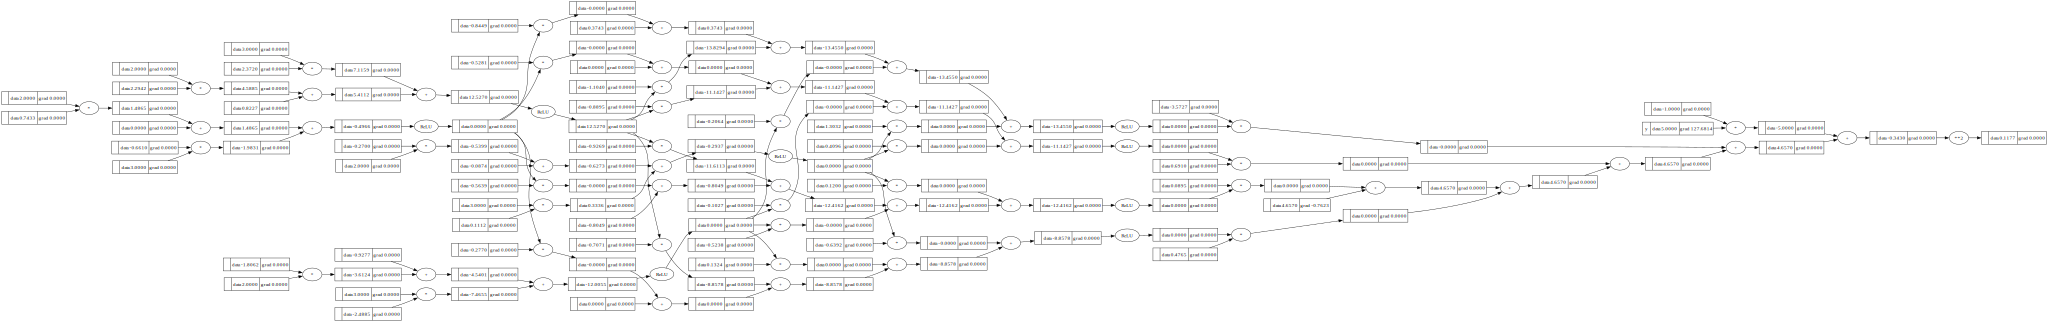

In [49]:
draw_dot(loss)

## Ejemplo final de Backprop

In [110]:
nin = 2
xs = [2.0, 3.0] ## Las 2 entradas
nouts = [4, 10, 1] ## 2 entradas, 4 neuronas, 4 neuronas, 1 neurona
y = Value(5, label='y') ## El valor real que queremos predecir

mlp = MLP(nin, nouts)
z = mlp(xs)

loss = (z-y)**2
print("Prediccion de la red:",z)
print("Loss de la red:", loss)

Prediccion de la red: Value(data=-2.2276079676819043, grad=0)
Loss de la red: Value(data=52.23831693449895, grad=0)


In [111]:
epoch = 50
lr = 0.05
for i in range(epoch):
    z = mlp(xs)
    loss = (z-y)**2
    lr = lr * 0.99

    print(f"Epoch {i+1} Loss: {loss.data}")

    for p in mlp.parameters():
        p.grad = 0
    
    loss.backward()

    for p in mlp.parameters():
        p.data = p.data - lr * p.grad

    

Epoch 1 Loss: 52.23831693449895
Epoch 2 Loss: 4.887093960005222
Epoch 3 Loss: 0.7227990476704594
Epoch 4 Loss: 0.19537573775474518
Epoch 5 Loss: 0.033288235110217834
Epoch 6 Loss: 0.006409749356257401
Epoch 7 Loss: 0.0010600399304555165
Epoch 8 Loss: 0.0001696295975675878
Epoch 9 Loss: 2.4883851045632816e-05
Epoch 10 Loss: 3.413251451293573e-06
Epoch 11 Loss: 4.3309239856287307e-07
Epoch 12 Loss: 5.0896762577864597e-08
Epoch 13 Loss: 5.520028766704199e-09
Epoch 14 Loss: 5.513885422438609e-10
Epoch 15 Loss: 5.058399878367968e-11
Epoch 16 Loss: 4.249951079162154e-12
Epoch 17 Loss: 3.2599773566060415e-13
Epoch 18 Loss: 2.2753363961158235e-14
Epoch 19 Loss: 1.4397456487574602e-15
Epoch 20 Loss: 8.226178800072074e-17
Epoch 21 Loss: 4.225495564658446e-18
Epoch 22 Loss: 1.941898047109197e-19
Epoch 23 Loss: 7.942026172028315e-21
Epoch 24 Loss: 2.8733250702868935e-22
Epoch 25 Loss: 9.129963728109523e-24
Epoch 26 Loss: 2.5361010355859786e-25
Epoch 27 Loss: 6.1089388500315154e-27
Epoch 28 Loss: 1